HYPOTHESIS 1

Qn: Do male and female penguins differ significantly in body mass within the same species?

Hypothesis: Male penguins are significantly heavier than female penguins within each species.

Conclusion: Males consistently show higher body mass than females, indicating sexual dimorphism in penguins.

In [1]:
import pandas as pd
df = pd.read_csv("penguins.csv")
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())


(344, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000

HYPOTHESIS 2

Qn: Do larger penguins have proportionally longer flippers?

Hypothesis: There is a strong positive correlation between body mass and flipper length across all penguins.

Conclusion: Heavier penguins tend to have longer flippers, suggesting proportional body scaling.

In [2]:
df_clean = df.dropna(subset=['bill_length_mm', 'flipper_length_mm', 'body_mass_g'])
df_clean['sex'] = df_clean['sex'].fillna('Unknown')
print(df_clean.isnull().sum())
print(df_clean['species'].value_counts())


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64


C:\Users\Elahe\AppData\Local\Temp\ipykernel_9152\2033303180.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['sex'] = df_clean['sex'].fillna('Unknown')


HYPOTHESIS 3: Morphological Differences

Qn: Do penguin species differ in their morphological features such as bill length, flipper length, and body mass?
Hypothesis: Each species exhibits distinct patterns in morphology, with Gentoos being the largest, Chinstraps intermediate, and Adelies smallest.
Conclusion: Histograms, boxplots, and scatterplots show clear differences in bill length, flipper length, and body mass among species, confirming distinct morphological characteristics.

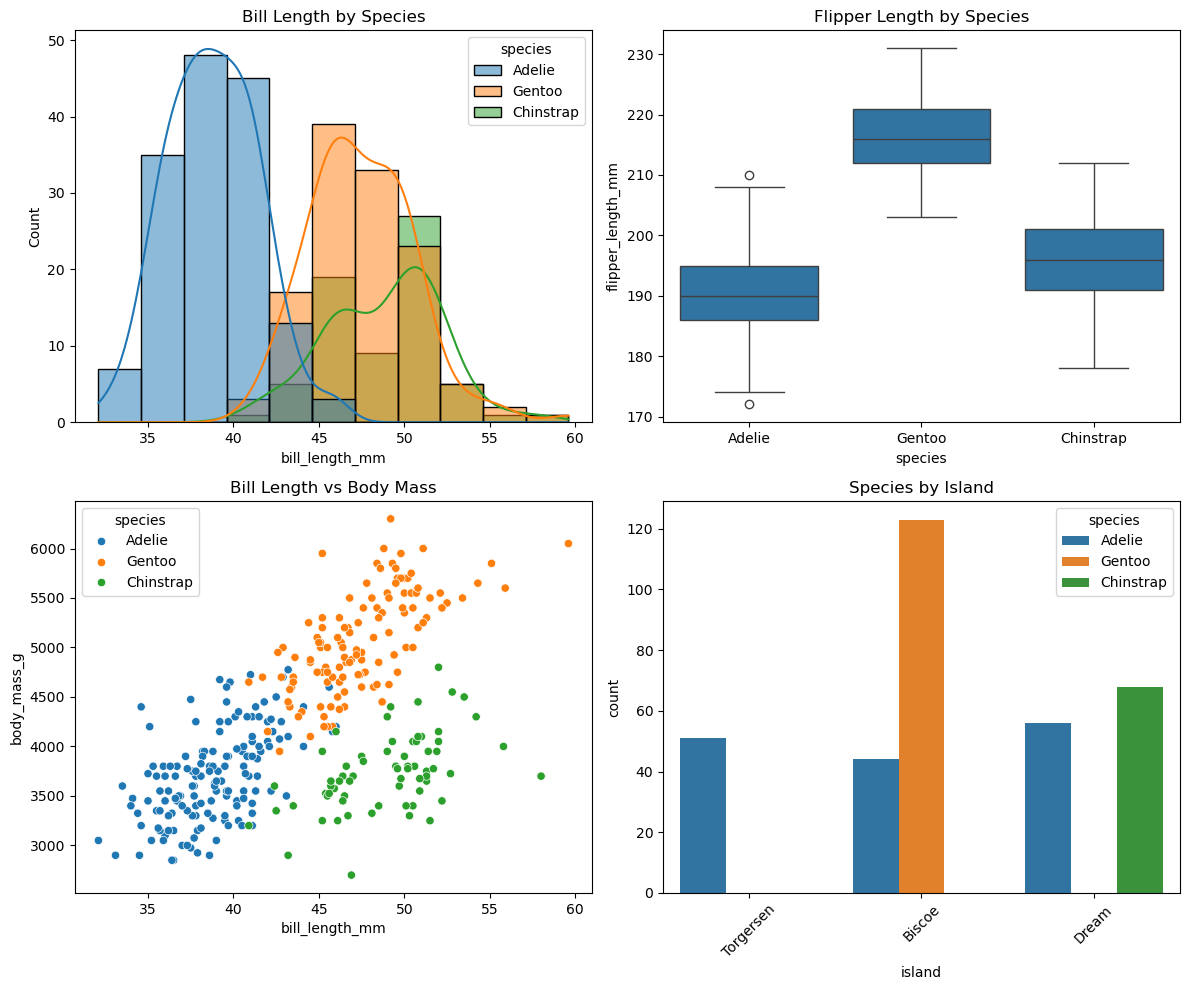

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(data=df_clean, x='bill_length_mm', hue='species', kde=True, ax=ax[0, 0])
ax[0, 0].set_title("Bill Length by Species")

sns.boxplot(data=df_clean, x='species', y='flipper_length_mm', ax=ax[0, 1])
ax[0, 1].set_title("Flipper Length by Species")

sns.scatterplot(data=df_clean, x='bill_length_mm', y='body_mass_g', hue='species', ax=ax[1, 0])
ax[1, 0].set_title("Bill Length vs Body Mass")

sns.countplot(data=df_clean, x='island', hue='species', ax=ax[1, 1])
ax[1, 1].set_title("Species by Island")
ax[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


HYPOTHESIS 4: Species Distribution by Island

Qn: Is penguin species distribution influenced by island geography?
Hypothesis: Certain species are predominantly found on specific islands, indicating that geography affects species presence.
Conclusion: Countplots show strong clustering of species per island: some islands host multiple species with variation (e.g., Biscoe), while others have only one dominant species. Geography is a key factor in distribution.

In [4]:
insights = pd.DataFrame({
    "Observation": [
        "Gentoo penguins are the heaviest and have the longest bills",
        "Chinstrap penguins have intermediate flipper lengths",
        "Penguin species are strongly linked to specific islands"
    ],
    "Implication": [
        "Gentoo are adapted for efficient swimming",
        "Chinstrap show moderate body size",
        "Geography influences species distribution"
    ]
})
print(insights)


                                         Observation  \
0  Gentoo penguins are the heaviest and have the ...   
1  Chinstrap penguins have intermediate flipper l...   
2  Penguin species are strongly linked to specifi...   

                                 Implication  
0  Gentoo are adapted for efficient swimming  
1          Chinstrap show moderate body size  
2  Geography influences species distribution  


HYPOTHESIS 5: Feature Correlation and Species Separation

Qn: Are morphological features correlated, and can they be used to distinguish species?
Hypothesis: Features such as bill length, bill depth, flipper length, and body mass are correlated, and the combination of these features separates species into distinct clusters.
Conclusion: Correlation heatmaps show moderate positive correlations between features, and pairplots reveal distinct clusters for each species, suggesting that morphology can reliably identify species.

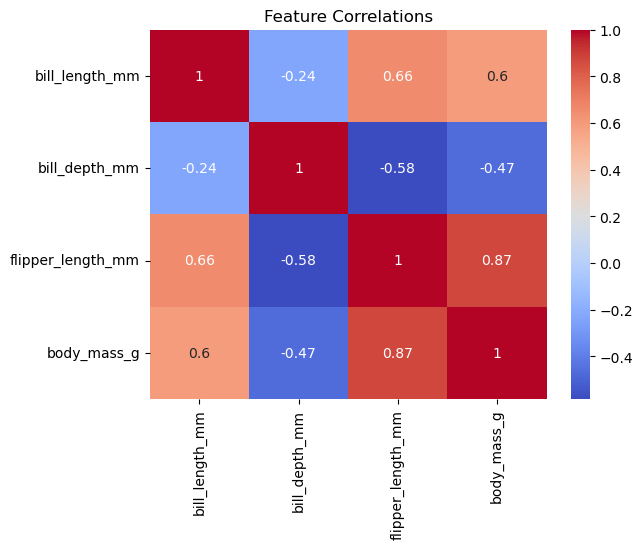

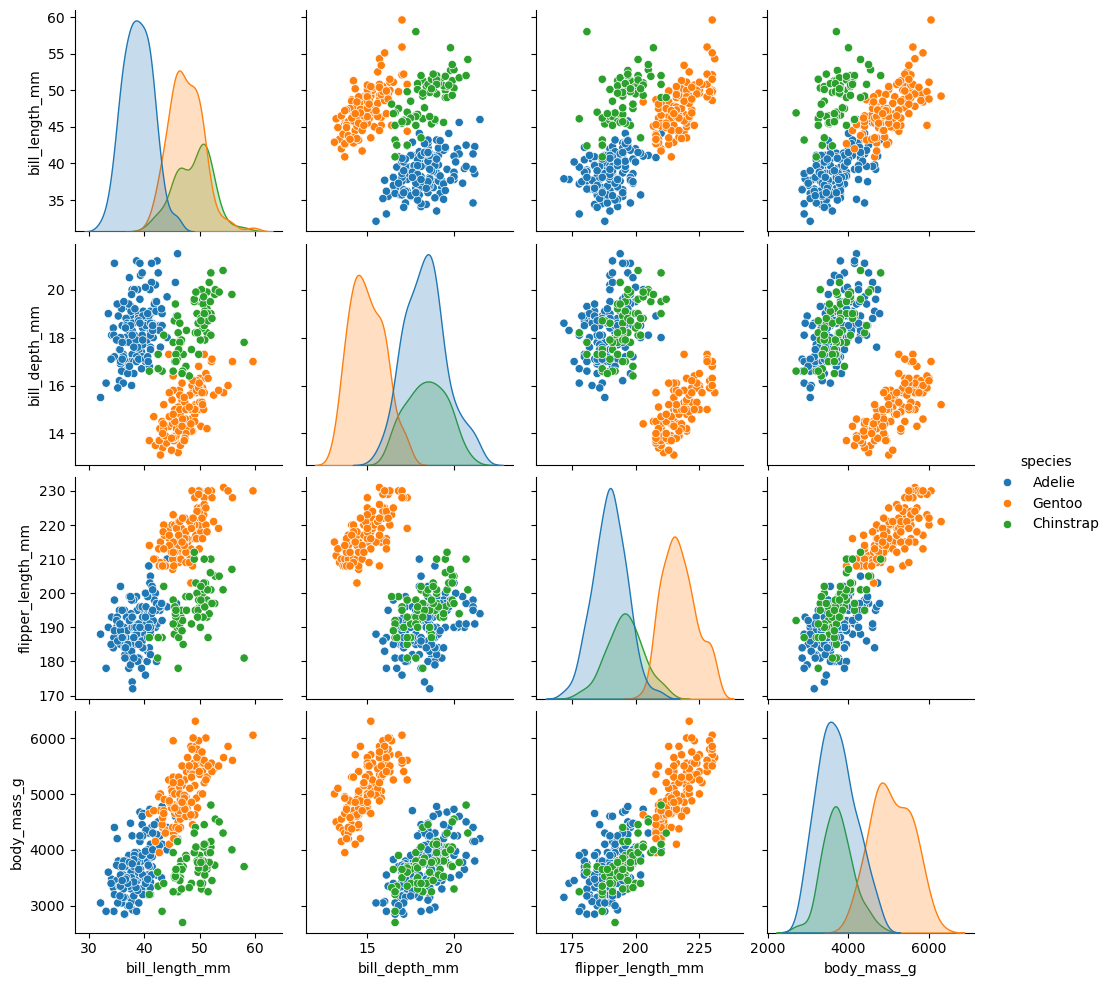

In [5]:
corr = df_clean[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlations")
plt.show()

sns.pairplot(df_clean, hue='species', vars=['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g'])
plt.show()
